In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from tqdm.notebook import tqdm
import numpy as np
np.set_printoptions(suppress=True)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from simulators import NestedModelFamily
from simulators.benchmarks import DDM
from adapters import Adapter

# Transformer

In [3]:
class MAB(nn.Module):
    """
    Multihead Attention Block using torch.nn.MultiheadAttention.

    Args:
        dim_Q:  feature dim of Q input  (B, T_q, dim_Q)
        dim_K:  feature dim of K input  (B, T_k, dim_K)
        dim_V:  internal/embed dim for attention and output
        num_heads: number of attention heads
        ln: whether to use LayerNorm before/after the FFN residual
    """
    def __init__(self, query_dim: int, key_dim: int = None, num_heads: int = 4, ln: bool = False, dropout: float = 0.0):
        super().__init__()

        if key_dim is None:
            key_dim = query_dim

        # Built-in MHA; batch_first=True to accept (B, T, C)
        self.attn = nn.MultiheadAttention(
            embed_dim=query_dim,
            kdim=key_dim,
            vdim=key_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.ln0 = nn.LayerNorm(query_dim) if ln else None
        self.ln1 = nn.LayerNorm(query_dim) if ln else None

        self.fc_o = nn.Linear(query_dim, query_dim)

    def forward(self,
        query: torch.Tensor,
        key: torch.Tensor,
        attn_mask: torch.Tensor = None,
        key_padding_mask: torch.Tensor = None
    ) -> torch.Tensor:
        """
        Q: (B, T_q, dim_Q)
        K: (B, T_k, dim_K) — used for both keys and values
        attn_mask: optional (T_q, T_k) or (B*num_heads, T_q, T_k)
        key_padding_mask: optional (B, T_k), True for PAD positions
        """

        attn_out, _ = self.attn(
            query=query,
            key=key,
            value=key,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )

        # 3) First residual (q + attention), optional LayerNorm
        out = query + attn_out
        if self.ln0 is not None:
            out = self.ln0(out)

        # 4) Simple FFN + residual (match original: ReLU then linear)
        out = out + F.gelu(self.fc_o(out))
        if self.ln1 is not None:
            out = self.ln1(out)

        return out


class SAB(nn.Module):
    def __init__(self, input_dim: int, num_heads: int = 4, ln: bool = False, dropout: float = 0.0):
        super().__init__()
        self.mab = MAB(query_dim=input_dim, num_heads=num_heads, ln=ln, dropout=dropout)

    def forward(self, X, attn_mask=None, key_padding_mask=None):
        return self.mab(X, X, attn_mask=attn_mask, key_padding_mask=key_padding_mask)

class PMA(nn.Module):
    def __init__(
        self,
        input_dim: int,
        seed_dim: int,
        num_heads: int = 4,
        num_seeds: int = 1,
        ln: bool = False,
        dropout: float = 0.0
):
        super().__init__()
        self.S = nn.Parameter(torch.Tensor(1, num_seeds, seed_dim))
        nn.init.xavier_uniform_(self.S)
        self.mab = MAB(query_dim=seed_dim, key_dim=input_dim, num_heads=num_heads, ln=ln, dropout=dropout)

    def forward(self, X):
        return self.mab(self.S.repeat(X.size(0), 1, 1), X)

In [4]:
class Encoder(nn.Module):

    def __init__(
        self,
        input_dim: int,
        embed_dim: int = 64,
        seed_dim: int = 128,
        num_layers: int = 3,
        num_seeds: int = 10,
        num_heads: int = 4,
        ln: bool = False,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()
        assert num_layers >= 1, "num_layers must be >= 1"

        self.input_embedding = nn.Linear(input_dim, embed_dim)

        self.layers = nn.ModuleList(
            [SAB(input_dim=embed_dim, num_heads=num_heads, ln=ln, dropout=dropout)
             for _ in range(num_layers)]
        )
        self.post_dropout = nn.Dropout(layer_dropout) if layer_dropout > 0 else nn.Identity()

        self.pma = PMA(
            input_dim=embed_dim,
            seed_dim=seed_dim,
            num_seeds=num_seeds,
            num_heads=num_heads,
            ln=ln,
            dropout=dropout
        )

    def forward(self, x, attn_mask=None):
        """
        X: (B, T, C)
        attn_mask: optional (T, T) or (B*num_heads, T, T)
        key_padding_mask: optional (B, T) with True for PAD tokens
        """

        out = self.input_embedding(x)

        for sab in self.layers:
            out = sab(out, attn_mask=attn_mask)
            out = self.post_dropout(out)

        pooled = self.pma(out)
        return pooled

In [5]:
class Decoder(nn.Module):

    def __init__(
        self,
        input_dim: int = 2,
        seed_dim: int = 128,
        proj_dim: int = 64,
        num_layers: int = 3,
        num_heads: int = 4,
        ln: bool = False,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()
        assert num_layers >= 1, "num_layers must be >= 1"

        self.input_proj = nn.Linear(input_dim, proj_dim)

        self.layers = nn.ModuleList(
            [MAB(query_dim=proj_dim, key_dim=seed_dim, num_heads=num_heads, ln=ln, dropout=dropout)
             for _ in range(num_layers)]
        )
        self.post_dropout = nn.Dropout(layer_dropout) if layer_dropout > 0 else nn.Identity()

        self.output_proj = nn.Linear(proj_dim, 2)
        self.num_heads = num_heads

    def forward(self, query, key, query_mask=None):
        """
        X: (B, T, C)
        attn_mask: optional (T, T) or (B*num_heads, T, T)
        key_padding_mask: optional (B, T) with True for PAD tokens
        """

        out = self.input_proj(query)

        if query_mask is not None:
            B, Tq = query_mask.shape
            Tk = key.shape[1]

            # (B, Tq): True = block
            q_block = query_mask == 0

            #  (B*H, Tq, Tk) - repeat batch mask across heads
            attn_mask_bt = q_block.unsqueeze(-1).expand(B, Tq, Tk)
            attn_mask = attn_mask_bt.repeat_interleave(self.num_heads, dim=0)
        else:
            attn_mask = None

        for mab in self.layers:
            out = mab(query=out, key=key, attn_mask=attn_mask)
            out = self.post_dropout(out)

            if query_mask is not None:
                out = out * query_mask[..., None]

        mu, log_var = self.output_proj(out).chunk(2, dim=-1)

        if query_mask is not None:
            mu = mu * query_mask[..., None]
            log_var = log_var * query_mask[..., None]

        return mu, log_var

In [6]:
class BayesGPTv1(nn.Module):

    def __init__(
        self,
        encoder_input_dim: int = 17,
        decoder_input_dim: int = 2,
        proj_dim: int = 64,
        encoder_num_layers: int = 3,
        decoder_num_layers: int = 3,
        encoder_num_heads: int = 4,
        decoder_num_heads: int = 4,
        num_seeds: int = 10,
        seed_dim: int = 128,
        ln: bool = True,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()

        self.encoder = Encoder(
            input_dim=encoder_input_dim,
            num_layers=encoder_num_layers,
            num_seeds=num_seeds,
            seed_dim=seed_dim,
            num_heads=encoder_num_heads,
            ln=ln,
            dropout=dropout,
            layer_dropout=layer_dropout,
        )

        self.decoder = Decoder(
            input_dim=decoder_input_dim,
            seed_dim=seed_dim,
            proj_dim=proj_dim,
            num_layers=decoder_num_layers,
            num_heads=decoder_num_heads,
            ln=ln,
            dropout=dropout,
            layer_dropout=layer_dropout,
        )

    def forward(self, input_data, param_indices, regressor_indices, params_mask=None):

        encoder_tokens = self.encoder(input_data)

        pos_embeddings = torch.cat([param_indices, regressor_indices], dim=-1)

        decoded_mu, decoded_logvar = self.decoder(
            query=pos_embeddings,
            key=encoder_tokens,
            query_mask=params_mask
        )

        return decoded_mu, decoded_logvar

## Loss function

In [7]:
def loss(true_params, mu, logvar, param_masks) -> torch.Tensor:
    """
    Heteroskedastic Gaussian NLL with masking.
    """

    mu = mu.squeeze(dim=-1)
    logvar = logvar.squeeze(dim=-1)

    inv_var = torch.exp(-logvar)
    nll = 0.5 * ((true_params - mu)**2 * inv_var + logvar)

    nll_masked = nll * param_masks
    denom = param_masks.sum(dim=-1)
    return torch.mean(nll_masked.sum(dim=-1) / denom)

# Simulator using `NestedModelFamily`

We start with DDM

In [8]:
ddm_priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

In [9]:
model_family = NestedModelFamily(name="DDM", model=DDM(), prior_fun=ddm_priors)

In [10]:
samples = model_family.batch_sample(
    batch_size=8,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "decay"},
        fixed_intrinsics={"s_tau"}
    ),
    num_obs=200,
    flatten_param_outputs=True
)

In [11]:
adapter = Adapter()

## BayesGPT

In [12]:
bayesgpt = BayesGPTv1(encoder_num_layers=4, decoder_num_layers=4, seed_dim=64, num_seeds=10)

In [14]:
grad_clip_norm = 5.
batch_size = 32
epochs = 500
steps_per_epoch = 500
learning_rate = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bayesgpt.to(device)
bayesgpt.train()#### HByp

optimizer = Adam(bayesgpt.parameters(), lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

for ep in range(epochs):
    pbar = tqdm(total=steps_per_epoch, desc=f"Epoch {ep+1}/{epochs}", miniters=100)

    for step in range(steps_per_epoch):

        samples = model_family.batch_sample(
            batch_size=batch_size,
            mask_randomizer_kwargs=dict(
                free_intrinsics={"v", "a", "tau", "s_v", "decay"},
                fixed_intrinsics={"s_tau"}
            ),
            num_obs=1000,
            flatten_param_outputs=True
        )

        adapted = adapter.adapt(samples, intrinsic_params=model_family.intrinsic_params)

        optimizer.zero_grad()

        mu, logvar = bayesgpt(
            adapted["input_data"],
            adapted["param_indices"],
            adapted["regressor_indices"],
            adapted["param_masks"]
        )

        L = loss(adapted["param_matrices"], mu, logvar, adapted["param_masks"])
        L.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(bayesgpt.parameters(), grad_clip_norm)

        optimizer.step()

        loss_val = L.detach().item()
        current_lr = scheduler.get_last_lr()[0]

        pbar.set_postfix(loss=f"{loss_val:.4f}", lr=f"{current_lr:.2e}")
        pbar.update(1)

    scheduler.step()
    pbar.close()

Epoch 1/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 3/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 4/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 5/500:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 186/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 187/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 188/500:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 189/500:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [84]:
adapted["param_masks"].shape

torch.Size([32, 186])

In [85]:
test_set = model_family.batch_sample(
        batch_size=100,
        mask_randomizer_kwargs=dict(
            free_intrinsics={"v", "a", "tau", "s_v", "decay"},
            fixed_intrinsics={"s_tau"}
        ),
        num_obs=200,
        flatten_param_outputs=True
)

adapted = adapter.adapt(samples, intrinsic_params=ddm_intrinsics)                   # user-provided

In [86]:
bayesgpt.eval()

mu, logvar = bayesgpt(adapted["input_data"], adapted["param_indices"], adapted["regressor_indices"])

In [87]:
true = adapted["param_matrices"][:, 5].detach().cpu().numpy()
pred = mu[:, 5].detach().cpu().numpy()

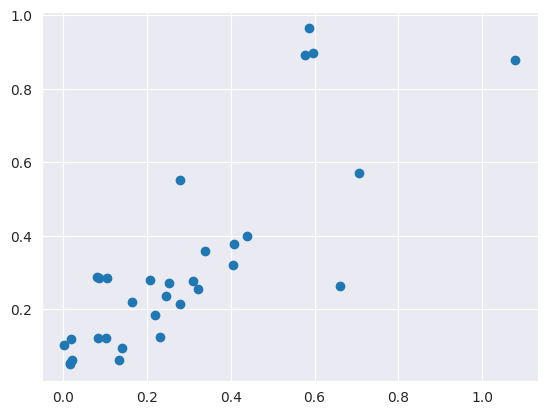

In [88]:
plt.scatter(true, pred)

In [89]:
from viz import visualize_matrix

In [90]:
true_param_matrices = adapted["param_matrices"].detach().cpu().numpy()
true_param_matrices = true_param_matrices.reshape(batch_size, 31, len(ddm_intrinsics))

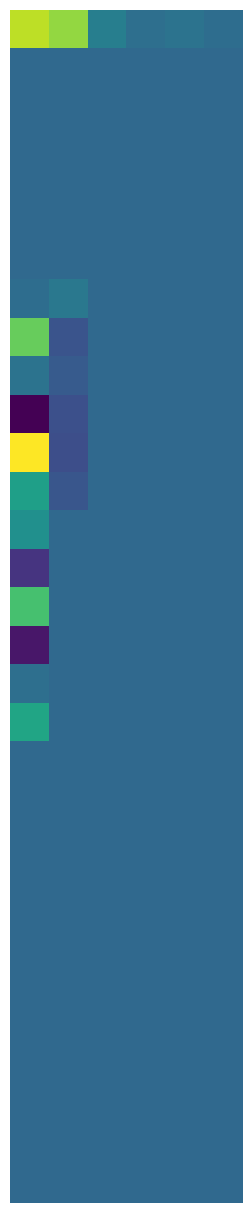

In [91]:
param_matrices_viz = visualize_matrix(true_param_matrices[0])

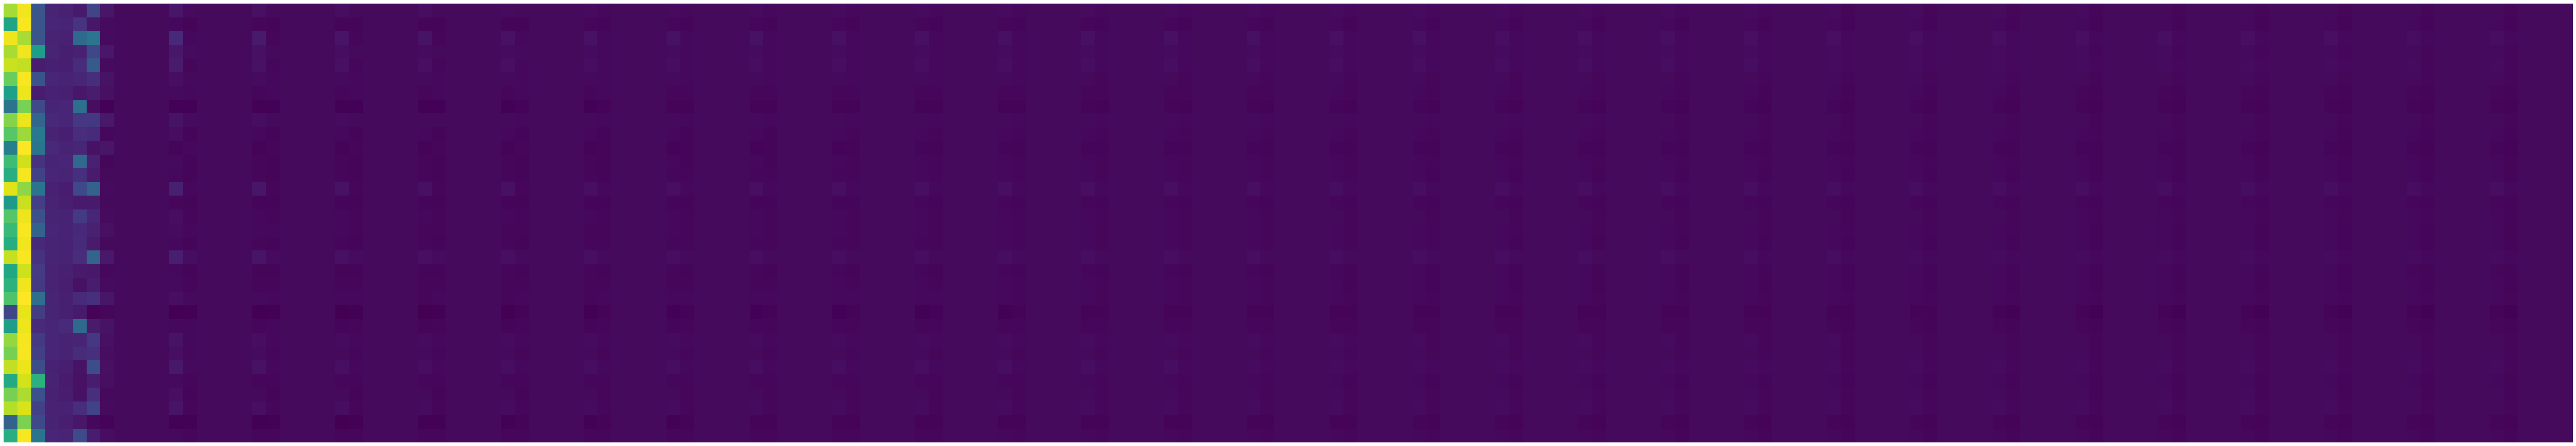

In [92]:
pred_matrices_viz = visualize_matrix(mu.detach().cpu().numpy()[:,:,0])

In [93]:
adapted["input_data"].shape

torch.Size([32, 200, 32])

In [94]:
adapted["param_matrices"].shape

torch.Size([32, 186])

In [95]:
num_intrinsic_params = len(ddm_intrinsics)

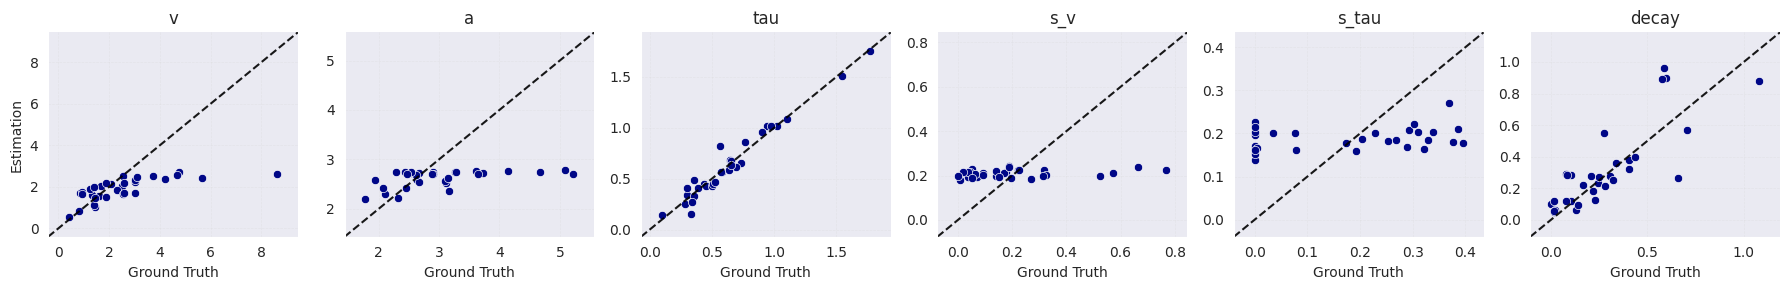

In [96]:
from utils.plot_utils import make_quadratic

true_set = adapted["param_matrices"].detach().cpu().numpy()
pred_set = mu.detach().cpu().numpy()[:,:,0]
f, axarr = plt.subplots(1, num_intrinsic_params, figsize=(3 * num_intrinsic_params, 3))

for i, ax in enumerate(axarr.flatten()):
    sns.scatterplot(x=true_set[:, i], y=pred_set[:, i], ax=ax, color="#000787")

    make_quadratic(ax, true_set[:, i], pred_set[:, i])

    ax.grid(True, color="lightgray", linestyle="--", linewidth=0.5, alpha=0.3)
    ax.set_xlabel("Ground Truth")
    if i % num_intrinsic_params == 0:
        ax.set_ylabel("Estimation")
    ax.set_title(ddm_intrinsics[i])
    sns.despine(ax=ax)

f.tight_layout()